In [1]:
import yaramod
import yara
import re
import argparse
import subprocess
import pandas as pd
from tqdm import tqdm

In [2]:
file_path='/home/mabon/research/Autoyara/YaraResults/yaraRules/originalBloomFilters/sdhash/Th50/cluster_0/1/yaraRule.yar'

In [3]:
try:
    rules = yara.compile(filepath=file_path)
    print("YARA rule is valid.")
except yara.SyntaxError as e:
    print(f"Syntax error in YARA rules: {e}")
except yara.Error as e:
    print(f"Error compiling YARA rules: {e}")
    
    
    # Scan the test file
# matches = rules.match('/mnt/data_disk1/mabon/datacopy/Honeypots/file.1020265.exe')
# for match in matches:
#     print(f"Rule matched: {match.rule}")
#     print(f"Strings found: {match.strings}")

YARA rule is valid.


In [24]:
def test_rule(yara_python_rule, files):
    # Runs the rule on all samples in a directory
    matchesCount = 0
    total = 0

    for file in files:
        total += 1
        try:
            matches = yara_python_rule.match(file)
            if matches:
                matchesCount += 1
        except:
            continue
            
    return matchesCount,total

In [15]:
def get_files_by_all_clusters(df):
    """
    Get all file paths organized by their cluster labels, sorted by cluster size in descending order.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing File_Path and Cluster_Label columns
    
    Returns:
    dict: Dictionary where keys are cluster labels and values are lists of file paths,
          ordered by cluster size (largest to smallest)
    """
    # Group by Cluster_Label and get lists of File_Path
    clustered_files = df.groupby('Cluster_Label')['File_Path'].apply(list).to_dict()
    
    # Sort by length of file lists and create new ordered dictionary
    sorted_items = sorted(clustered_files.items(), key=lambda x: len(x[1]), reverse=True)
    return dict(sorted_items)
    

In [22]:
csv_file='/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/th50.csv'
df = pd.read_csv(csv_file)
all_cluster_files = get_files_by_all_clusters(df)
    # Filter out clusters with fewer than two elements
valid_clusters= {k: v for k, v in all_cluster_files.items() if len(v) >= 2}


In [27]:
def evaluateRule(rules,valid_clusters):
    # Initialize an empty list to store results
    results = []
    
    # Iterate through clusters
    for cluster, file_list in tqdm(valid_clusters.items(), desc="Processing clusters"):
        matches, total = test_rule(rules, file_list)
        if total > 0:  # Avoid division by zero
            tprate = matches / total
            # Append results as a dictionary
            results.append({
                'cluster': cluster,
                'matches': matches,
                'total': total,
                'TPrate': tprate
            })
        else:  # Avoid division by zero
            tprate = 0
            # Append results as a dictionary
            results.append({
                'cluster': cluster,
                'matches': matches,
                'total': total,
                'TPrate': tprate
            })
    
    return (pd.DataFrame(results))
    

Processing clusters: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 5379/5379 [00:16<00:00, 332.60it/s]


In [ ]:
'/mnt/data_disk1/mabon/datacopy/

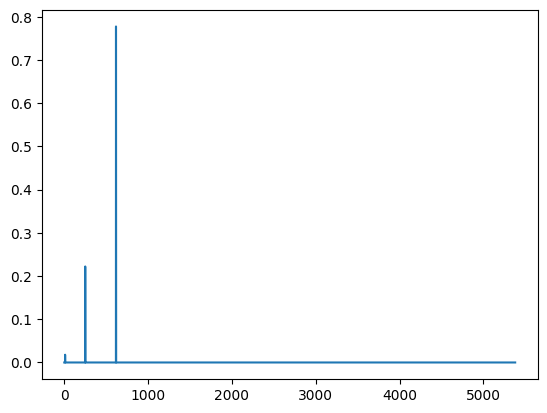

In [32]:
import matplotlib.pyplot as plt

plt.plot(list(df['TPrate']))